# Results 

This notebook presents the results obtained from preparing the GHZ state with both 3 and 5 qubits.

The results reported here were obtained by performing hyperparameter optimisation for each model using Optuna. Specifically, we explored 10 different hyperparameters for each model, and to ensure more representative results, each configuration was run five times.

## 3 Qubit GHZ preparation

Below, we present the results obtained from preparing the GHZ state with 3 qubits.

In [1]:
import matplotlib.pylab as plt
import numpy as np
import json
import sys
sys.path.insert(1, '../results/')

In [2]:
def read_results(path, name):
    with open(f"{path}{name}.json", 'r') as f:
        results = json.load(f)  
    return results  

path_folder = "../results/"
results_spsa = read_results(path_folder, "best_trial_3ghz_spsa")
results_bo_observables = read_results(path_folder, "best_trial_3ghz_bo_observables")
results_bo_fidelity = read_results(path_folder, "best_trial_3ghz_bo_fidelity")
results_ppo = read_results(path_folder, "best_trial_3ghz_rl_ppo")
results_td3 = read_results(path_folder, "best_trial_3ghz_rl_td3")


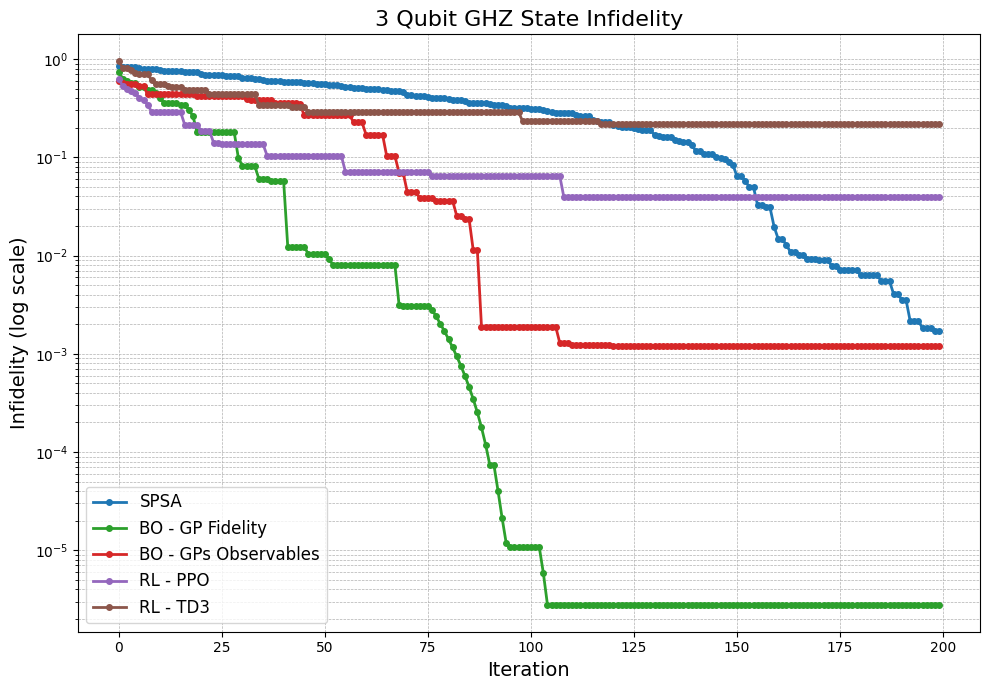

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

n_samples = np.arange(len(results_bo_fidelity['best_metrics']['history_best_fidelity_runs'][0]))
ax.plot(n_samples, 1-np.mean(np.array(results_spsa['best_metrics']['history_best_fidelity_runs']),0),'-o', label='SPSA', linewidth=2, markersize=4, color='C0')
ax.plot(n_samples, 1-np.mean(np.array(results_bo_fidelity['best_metrics']['history_best_fidelity_runs']),0),'-o', label='BO - GP Fidelity', linewidth=2, markersize=4, color='C2')
ax.plot(n_samples, 1-np.mean(np.array(results_bo_observables['best_metrics']['history_best_fidelity_runs']),0),'-o', label='BO - GPs Observables', linewidth=2, markersize=4, color='C3')
ax.plot(n_samples, 1-np.mean(np.array(results_ppo['best_metrics']['history_best_fidelity_runs']),0),'-o', label='RL - PPO', linewidth=2, markersize=4, color='C4')
ax.plot(n_samples, 1-np.mean(np.array(results_td3['best_metrics']['history_best_fidelity_runs']),0),'-o', label='RL - TD3', linewidth=2, markersize=4, color='C5')


plt.ylabel('Infidelity (log scale)', fontsize=14)
plt.xlabel('Iteration', fontsize=14)
plt.title('3 Qubit GHZ State Infidelity', fontsize=16)
plt.yscale('log')
plt.legend(loc='lower left', fontsize=12)
plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig('../figures/results_3_qubit_GHZ_infidelity.png', bbox_inches='tight', dpi=300)
plt.show()


### Results Analysis: 

The figure above reveals that Bayesian optimisation-based models consistently outperform others, achieving remarkably low infidelities. Notably, the *BO - GPs Fidelity* model reaches infidelity values below $10^{-5}$. The rapid convergence of these models is particularly impressive, as they produce excellent results within just a few iterations.


In contrast, the RL models struggle to achieve low infidelity values. The SPSA model shows results comparable to those of the *BO - GPs Observables* model, although it converges more slowly. 

While increasing the number of iterations can enhance performance across all models, it's essential to consider the computational trade-offs:

- For most models, additional iterations generally lead to improved results without significant computational overhead.

- However, Bayesian Optimisation methods face a notable challenge: as the number of iterations increases, the algorithm's complexity grows cubically, which can significantly impact computational efficiency. 

##  5 qubit GHZ preparation
### Challenges in Preparing 5-Qubit GHZ States:

Preparing a 5-qubit GHZ state is significantly more complex than a 3-qubit version due to:

-   Larger circuit size
-   More parameters to optimise
-   Increased accumulated gate errors
-   Greater susceptibility to decoherence

In [8]:
results_spsa = read_results(path_folder, "best_trial_5ghz_spsa")
results_bo_observables = read_results(path_folder, "best_trial_5ghz_bo_observables")
results_bo_fidelity = read_results(path_folder, "best_trial_5ghz_bo_fidelity")
results_ppo = read_results(path_folder, "best_trial_5ghz_rl_ppo")
results_td3 = read_results(path_folder, "best_trial_5ghz_rl_td3")


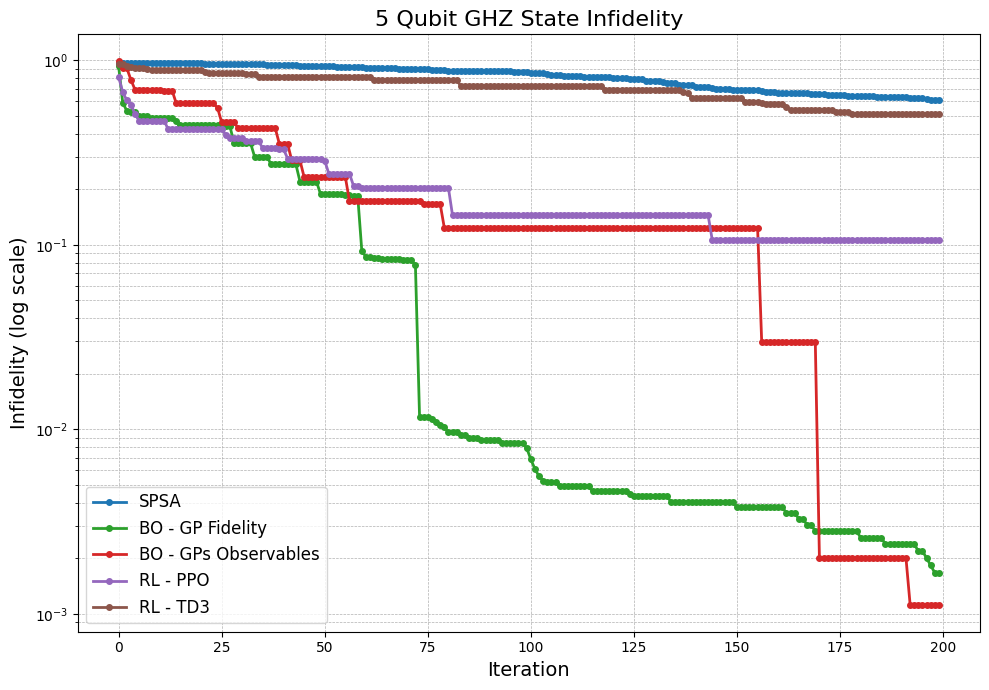

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

n_samples = np.arange(len(results_bo_fidelity['best_metrics']['history_best_fidelity_runs'][0]))
ax.plot(n_samples, 1-np.mean(np.array(results_spsa['best_metrics']['history_best_fidelity_runs']),0),'-o', label='SPSA', linewidth=2, markersize=4, color='C0')
ax.plot(n_samples, 1-np.mean(np.array(results_bo_fidelity['best_metrics']['history_best_fidelity_runs']),0),'-o', label='BO - GP Fidelity', linewidth=2, markersize=4, color='C2')
ax.plot(n_samples, 1-np.mean(np.array(results_bo_observables['best_metrics']['history_best_fidelity_runs']),0),'-o', label='BO - GPs Observables', linewidth=2, markersize=4, color='C3')
ax.plot(n_samples, 1-np.mean(np.array(results_ppo['best_metrics']['history_best_fidelity_runs']),0),'-o', label='RL - PPO', linewidth=2, markersize=4, color='C4')
ax.plot(n_samples, 1-np.mean(np.array(results_td3['best_metrics']['history_best_fidelity_runs']),0),'-o', label='RL - TD3', linewidth=2, markersize=4, color='C5')

plt.ylabel('Infidelity (log scale)', fontsize=14)
plt.xlabel('Iteration', fontsize=14)
plt.title('5 Qubit GHZ State Infidelity', fontsize=16)
plt.yscale('log')
plt.legend(loc='lower left', fontsize=12)
plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig('../figures/results_5_qubit_GHZ_infidelity.png', bbox_inches='tight', dpi=300)
plt.show()



### Results Analysis: 

All models show a considerable increase in infidelity compared to the 3-qubit GHZ state. Key observations:

-    No model achieved infidelities lower than $10^{-3}$

### Computational Considerations:

-   Bayesian optimisation with observable surrogate models increases the computational cost considerably with increasing number of qubits
-   Achieving good results requires more iterations, which is computationally demanding

These challenges highlight the increasing complexity in quantum state preparation as the number of qubits grows.

# Main conclusion

## General Observations


- While the current results are promising, they are not yet conclusive. Further experimentation—across different circuit architectures, optimisation settings, iteration budgets, and target states—is necessary to reach robust conclusions. Although the current codebase supports such experimentation, computational limitations prevented a broader analysis.

- A valuable direction for future work would be to compare these ML-based approaches with traditional quantum optimal control methods such as GRAPE. Ideally, this should be done using standardized benchmarks, as the current landscape suffers from a lack of consistent experimental frameworks, making comparisons across different studies challenging.

## Model-Specific Observations


Based on the extensive set of experiments conducted, several conclusions, observations, and suggestions for future work can be drawn:

- BO produced excellent results, achieving high fidelity with relatively few iterations. However, this performance comes at a significant computational cost, particularly in scenarios involving multiple qubits, a large number of gates, or extensive datasets.

- When comparing the use of a single surrogate model (to directly estimate fidelity) versus multiple surrogate models (one per observable), we observed no significant improvement in infidelity from the latter approach. However, this conclusion is based solely on the experiments performed and may not generalize to other problems.

- Using multiple surrogate models incurs substantial computational overhead, primarily due to the training of one Gaussian Process per observable. Currently, these models are trained sequentially, but this process is highly parallelizable and could significantly accelerate the algorithm if implemented as such.

- RL-based models yielded lower fidelity than BO-based methods. However, they offer key advantages: fast training, scalability, and robust performance in high-dimensional spaces. These properties make RL appealing for experiments involving a large number of circuit iterations and tunable parameters.

- SPSA achieved results comparable to RL, although it was slightly slower in practice.

